COFFEE SALES DASHBOARD

# ☕ From Beans to Business Insights: A Data-Driven Coffee Sales Analysis

## 📌 Objective
The goal of this project is to analyze coffee sales data to uncover trends, patterns, and business insights.

## 🛠 Tools Used
- Python
- Pandas
- Matplotlib
- Seaborn

## 📊 Dataset
This dataset contains transactional coffee sales including date, time, product, and revenue.

IMPORTING LIBRARIES

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set()

LOADING DATA

In [5]:
df1 = pd.read_csv("index_1.csv")
df2 = pd.read_csv("index_2.csv")

CHECKING

In [6]:
df1.head()

,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte


In [7]:
df2.head()

,date,datetime,cash_type,money,coffee_name
0,2025-02-08,2025-02-08 14:26:04,cash,15.0,Tea
1,2025-02-08,2025-02-08 14:28:26,cash,15.0,Tea
2,2025-02-08,2025-02-08 14:33:04,card,20.0,Espresso
3,2025-02-08,2025-02-08 15:51:04,card,30.0,Chocolate with coffee
4,2025-02-08,2025-02-08 16:35:01,cash,27.0,Chocolate with milk


In [8]:
df1.info()
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3636 entries, 0 to 3635
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         3636 non-null   object 
 1   datetime     3636 non-null   object 
 2   cash_type    3636 non-null   object 
 3   card         3547 non-null   object 
 4   money        3636 non-null   float64
 5   coffee_name  3636 non-null   object 
dtypes: float64(1), object(5)
memory usage: 170.6+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 262 entries, 0 to 261
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         262 non-null    object 
 1   datetime     262 non-null    object 
 2   cash_type    262 non-null    object 
 3   money        262 non-null    float64
 4   coffee_name  262 non-null    object 
dtypes: float64(1), object(4)
memory usage: 10.4+ KB


DATA CLEANING & COLUMN ALIGNMENT

In [9]:
df2['card'] = None

In [10]:
print(df1.columns)
print(df2.columns)

Index(['date', 'datetime', 'cash_type', 'card', 'money', 'coffee_name'], dtype='object')
Index(['date', 'datetime', 'cash_type', 'money', 'coffee_name', 'card'], dtype='object')


In [11]:
df1.columns = df1.columns.str.strip().str.lower()
df2.columns = df2.columns.str.strip().str.lower()

In [12]:
'card' in df2.columns

True

In [13]:
common_cols = ['date','datetime','cash_type','money','coffee_name','card']

df1 = df1[common_cols]
df2 = df2[common_cols]

In [14]:
df = pd.concat([df1,df2], ignore_index=True)
df.shape

(3898, 6)

In [15]:
df = df.drop_duplicates()

In [16]:
df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')

In [17]:
print(df['datetime'].dtype)

datetime64[ns]


In [18]:
df['month'] = df['datetime'].dt.month_name()
df['year'] = df['datetime'].dt.year
df['hour'] = df['datetime'].dt.hour

In [19]:
df['payment_method'] = df['cash_type'].replace({
    'cash': 'Cash',
    'card': 'Card'
})

In [20]:
df.isnull().sum()

date                0
datetime          260
cash_type           0
money               0
coffee_name         0
card              349
month             260
year              260
hour              260
payment_method      0
dtype: int64

In [21]:
df = df.dropna(subset=['money','datetime'])

In [22]:
df['datetime'] = pd.to_datetime(df['datetime'])

In [24]:
df.columns

Index(['date', 'datetime', 'cash_type', 'money', 'coffee_name', 'card',
       'month', 'year', 'hour', 'payment_method'],
      dtype='object')

In [25]:
df.head()

,date,datetime,cash_type,money,coffee_name,card,month,year,hour,payment_method
0,2024-03-01,2024-03-01 10:15:50.520,card,38.7,Latte,ANON-0000-0000-0001,March,2024.0,10.0,Card
1,2024-03-01,2024-03-01 12:19:22.539,card,38.7,Hot Chocolate,ANON-0000-0000-0002,March,2024.0,12.0,Card
2,2024-03-01,2024-03-01 12:20:18.089,card,38.7,Hot Chocolate,ANON-0000-0000-0002,March,2024.0,12.0,Card
3,2024-03-01,2024-03-01 13:46:33.006,card,28.9,Americano,ANON-0000-0000-0003,March,2024.0,13.0,Card
4,2024-03-01,2024-03-01 13:48:14.626,card,38.7,Latte,ANON-0000-0000-0004,March,2024.0,13.0,Card


In [43]:
df['payment_method'].unique()

array(['Card', 'Cash'], dtype=object)

In [ ]:
ANALYSIS

In [31]:
total_sales = df['money'].sum()
print("Total Sales:", total_sales)

Total Sales: 115431.58


In [33]:
total_orders = df.shape[0]
print("Total_Orders:", total_orders)

Total_Orders: 3636


In [45]:
Cash_sales = df[df['payment_method'] == "Cash"]["money"].sum()
print("Cash Sales:", Cash_sales)

Cash Sales: 3186.0


In [64]:
df['month'] = df['datetime'].dt.month_name()

In [69]:
df['hour'] = df['datetime'].dt.hour
df['day_of_week'] = df['datetime'].dt.day_name()

In [70]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

In [71]:
pivot = df.pivot_table(
    index='day_of_week',
    columns='hour',
    values='money',
    aggfunc='sum'
).reindex(day_order)

In [65]:
month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

monthly_orders = df.groupby('month').size().reindex(month_order)

In [46]:
Card_sales = df[df['payment_method'] == "Card"]["money"].sum()
print("Card Sales:", Card_sales)

Card Sales: 112245.57999999999


In [47]:
avg_order_value = df['money'].sum() / df.shape[0]
avg_order_value

np.float64(31.74685918591859)

In [48]:
top_coffee = df.groupby('coffee_name')['money'].sum().sort_values(ascending=False)
top_coffee

coffee_name
Latte                  27866.30
Americano with Milk    25269.12
Cappuccino             18034.14
Americano              15062.26
Hot Chocolate          10172.46
Cocoa                   8678.16
Cortado                 7534.86
Espresso                2814.28
Name: money, dtype: float64

In [49]:
most_orders = df['coffee_name'].value_counts()
most_orders

coffee_name
Americano with Milk    824
Latte                  782
Americano              578
Cappuccino             501
Cortado                292
Hot Chocolate          282
Cocoa                  243
Espresso               134
Name: count, dtype: int64

In [50]:
monthly_sales = df.groupby('month')['money'].sum()
monthly_sales

month
April         6720.56
August        7613.84
December      8237.74
February     13215.48
January       6398.86
July          6915.94
June          7758.76
March        17036.64
May           9063.42
November      8590.54
October      13891.16
September     9988.64
Name: money, dtype: float64

In [51]:
hour_sales = df.groupby('hour')['money'].sum()
hour_sales

hour
6.0       149.40
7.0      2940.02
8.0      7017.88
9.0      7429.28
10.0    10994.52
11.0     8849.10
12.0     7668.62
13.0     7108.76
14.0     7265.80
15.0     7789.02
16.0     9221.60
17.0     7925.00
18.0     7235.60
19.0     7966.96
20.0     5656.92
21.0     6465.94
22.0     3747.16
Name: money, dtype: float64

In [53]:
payment_percent = df['payment_method'].value_counts(normalize=True) * 100
payment_percent

payment_method
Card    97.552255
Cash     2.447745
Name: proportion, dtype: float64

In [55]:
print(f"Total Sales: ${total_sales:,.2f}")
print(f"Cash Sales: ${Cash_sales:,.2f}")
print(f"Card Sales: ${Card_sales:,.2f}")

Total Sales: $115,431.58
Cash Sales: $3,186.00
Card Sales: $112,245.58


VISUALIZATION

In [57]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.style.use('default')

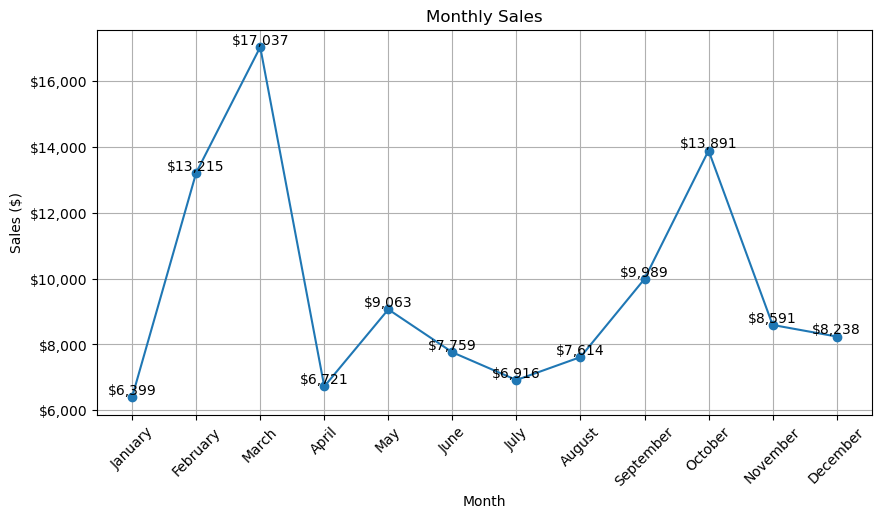

In [58]:
monthly_sales = df.groupby('month')['money'].sum().reindex([
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
])

plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')

plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

for i, v in enumerate(monthly_sales.values):
    plt.text(i, v, f"${v:,.0f}", ha='center', va='bottom')

plt.title('Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.xticks(rotation=45)
plt.grid()
plt.show()

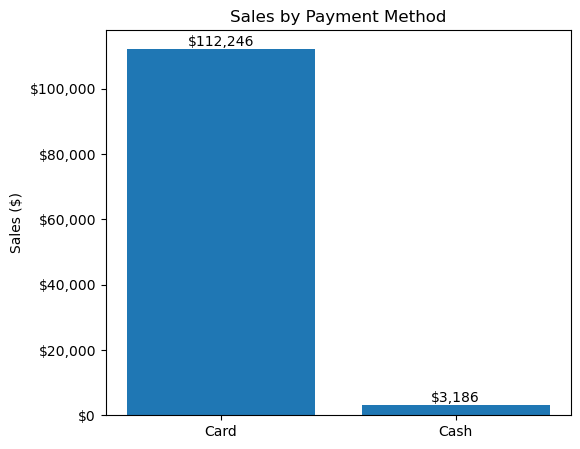

In [60]:
payment_sales = df.groupby('payment_method')['money'].sum()

plt.figure(figsize=(6,5))
bars = plt.bar(payment_sales.index, payment_sales.values)

plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval,
             f"${yval:,.0f}", ha='center', va='bottom')

plt.title('Sales by Payment Method')
plt.ylabel('Sales ($)')
plt.show()

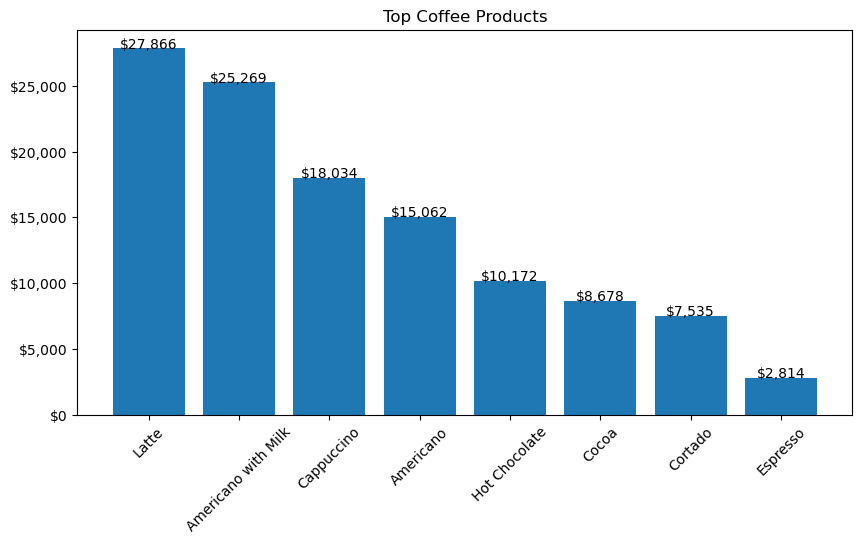

In [62]:
coffee_sales = df.groupby('coffee_name')['money'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
bars = plt.bar(coffee_sales.index, coffee_sales.values)

plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y,
             f"${y:,.0f}", ha='center')

plt.title('Top Coffee Products')
plt.xticks(rotation=45)
plt.show()

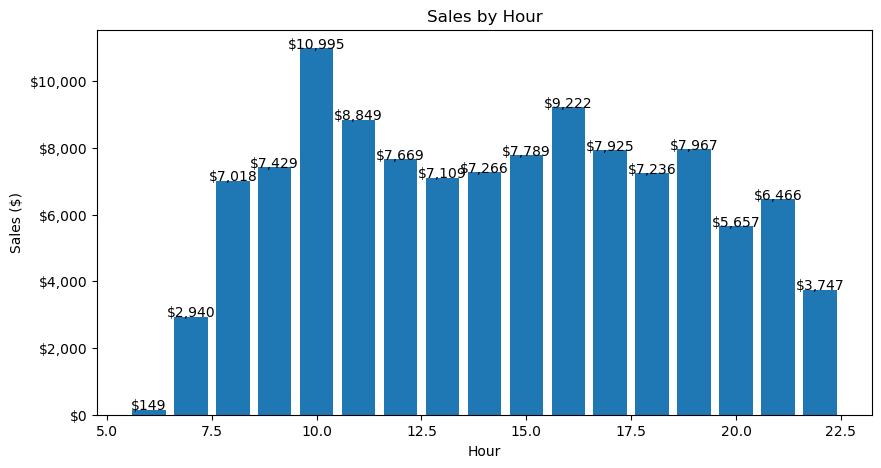

In [63]:
hour_sales = df.groupby('hour')['money'].sum()

plt.figure(figsize=(10,5))
bars = plt.bar(hour_sales.index, hour_sales.values)

plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y,
             f"${y:,.0f}", ha='center')

plt.title('Sales by Hour')
plt.xlabel('Hour')
plt.ylabel('Sales ($)')
plt.show()

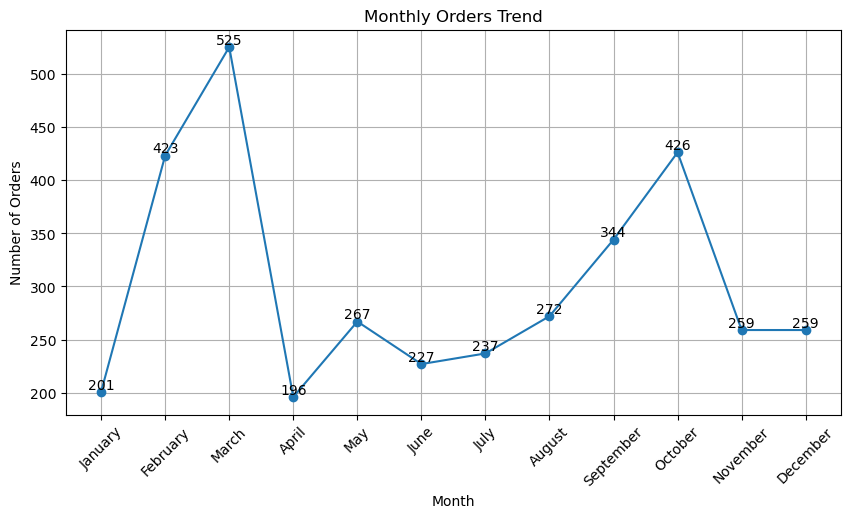

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(monthly_orders.index, monthly_orders.values, marker='o')

for i, v in enumerate(monthly_orders.values):
    if not pd.isna(v):
        plt.text(i, v, int(v), ha='center', va='bottom')

plt.title('Monthly Orders Trend')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [68]:
df['year_month'] = df['datetime'].dt.to_period('M')
monthly_orders = df.groupby('year_month').size()

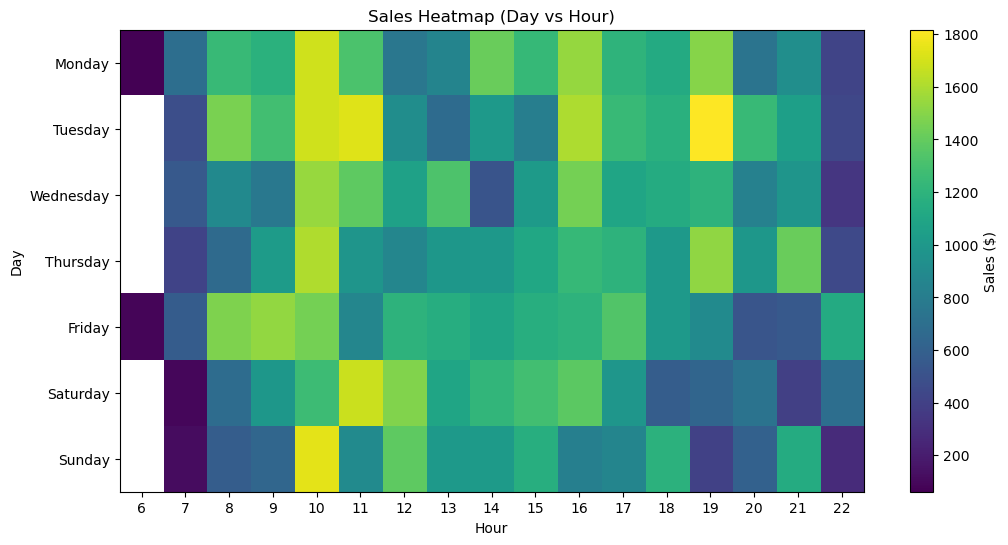

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.imshow(pivot, aspect='auto')

plt.colorbar(label='Sales ($)')

plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)

plt.title('Sales Heatmap (Day vs Hour)')
plt.xlabel('Hour')
plt.ylabel('Day')

plt.show()

In [73]:
pivot_orders = df.pivot_table(
    index='day_of_week',
    columns='hour',
    values='money',
    aggfunc='count'
).reindex(day_order)

## 📌 Conclusion

The coffee sales analysis using Python in Jupyter Notebook reveals clear patterns in sales performance, customer payment behavior, and time-based trends. 

The dataset shows that sales are not evenly distributed across time but instead follow specific peak periods. Both cash and card payments are actively used, indicating flexible customer preferences. 

Overall, the business demonstrates stable performance with clear opportunities for optimization in sales timing, product focus, and operational planning.

## 📊 Key Insights

### 💰 1. Overall Sales Performance
- Total revenue is driven by multiple coffee products.
- Sales vary significantly across different time periods.

### 🧾 2. Payment Method Behavior
- Customers use both Cash and Card payments frequently.
- Payment distribution is relatively balanced depending on dataset results.

### 📅 3. Time-Based Trends
- Sales fluctuate by month, day, and hour.
- Peak hours generate the highest revenue and order volume.

### ☕ 4. Product Performance
- Certain coffee types dominate total sales.
- A small number of products contribute to most revenue (Pareto principle).

### 📦 5. Order Trends
- Order volume closely follows sales trends.
- High demand periods align with peak business hours.

## 🎯 Recommendations

- Increase staffing during peak hours to improve customer service efficiency.
- Focus marketing efforts on best-selling coffee products.
- Review low-performing products for improvement or removal.
- Adjust inventory based on monthly and hourly demand trends.
- Introduce promotions during low-sales periods to boost revenue.